In [ ]:
import kagglehub
import pandas as pd
import numpy as np

# Download latest version
path = kagglehub.dataset_download("prachi13/customer-analytics")

print("Path to dataset files:", path)

# Load dataset into df
df = pd.read_csv("/kaggle/input/customer-analytics/Train.csv")

Using Colab cache for faster access to the 'customer-analytics' dataset.
Path to dataset files: /kaggle/input/customer-analytics


# 1. Add New Features (Feature Engineering)

In [ ]:
# 1. Cost-to-Weight Ratio
df['Cost_to_Weight_Ratio'] = df['Cost_of_the_Product'] / df['Weight_in_gms']

In [ ]:
# 2. Discount Percentage of Cost
df['Discount_Percentage'] = (df['Discount_offered'] / df['Cost_of_the_Product']) * 100

In [ ]:
# 3. Total Customer Engagement (prior purchases + care calls)
df['Total_Engagement'] = df['Customer_care_calls'] + df['Prior_purchases']

In [ ]:
# 4. High Value Order Flag (binary)
df['High_Value_Order'] = np.where(df['Cost_of_the_Product'] > 250, 1, 0)

In [ ]:
# 5. Weight Category (Light, Medium, Heavy)
df['Weight_Category'] = pd.cut(df['Weight_in_gms'],
                               bins=[0, 2000, 4000, np.inf],
                               labels=['Light', 'Medium', 'Heavy'])

In [ ]:
# 6. Discount Flag (binary)
df['Discount_Flag'] = np.where(df['Discount_offered'] > 0, 1, 0)

In [ ]:
# 7. Shipment Speed Indicator (ordinal encoding)
shipment_speed_map = {'Road': 1, 'Ship': 2, 'Flight': 3}
df['Shipment_Speed'] = df['Mode_of_Shipment'].map(shipment_speed_map)

In [ ]:
# 8. Is_Premium_Product (binary: high importance + high cost)
df['Is_Premium_Product'] = np.where((df['Product_importance'] == 'high') &
                                    (df['Cost_of_the_Product'] > 220), 1, 0)

In [ ]:
# 9. Effective_Cost_After_Discount
df['Effective_Cost_After_Discount'] = df['Cost_of_the_Product'] - df['Discount_offered']

In [ ]:
# 10. Calls_per_Purchase (normalized customer care calls by prior purchases)
df['Calls_per_Purchase'] = df['Customer_care_calls'] / (df['Prior_purchases'] + 1)

In [ ]:
# 11. Weight_per_Purchase (normalized weight by prior purchases)
df['Weight_per_Purchase'] = df['Weight_in_gms'] / (df['Prior_purchases'] + 1)

In [ ]:
# 12. Customer_Rating_Binary (1 if rating >= 4, else 0)
df['Customer_Rating_Binary'] = np.where(df['Customer_rating'] >= 4, 1, 0)

In [ ]:
# Save the updated dataset
df.to_csv("/content/customer_analytics_with_new_features.csv", index=False)

print("New dataset with engineered features saved as 'customer_analytics_with_new_features.csv'")
print("Shape of new dataset:", df.shape)

New dataset with engineered features saved as 'customer_analytics_with_new_features.csv'
Shape of new dataset: (10999, 23)


## 🔧 Feature Engineering Summary

| Feature Name                  | Formula / Definition                                                | Purpose / Business Logic                                                                 |
|--------------------------------|---------------------------------------------------------------------|------------------------------------------------------------------------------------------|
| `Cost_to_Weight_Ratio`         | `Cost_of_the_Product / Weight_in_gms`                               | Identifies expensive but lightweight products that may be sensitive in shipping.          |
| `Discount_Percentage`          | `(Discount_offered / Cost_of_the_Product) * 100`                    | Measures relative discount; high discounts may correlate with delayed deliveries.         |
| `Total_Engagement`             | `Customer_care_calls + Prior_purchases`                             | Captures customer’s interaction/loyalty and overall engagement with company.              |
| `High_Value_Order`             | `1 if Cost_of_the_Product > 250 else 0`                             | Flags premium orders that may get priority in shipping.                                   |
| `Weight_Category`              | Bins: Light (<2000g), Medium (2000–4000g), Heavy (>4000g)           | Categorizes orders by shipping weight, reflecting logistics handling differences.         |
| `Discount_Flag`                | `1 if Discount_offered > 0 else 0`                                  | Flags whether the product was purchased with a discount.                                  |
| `Shipment_Speed`               | Road=1, Ship=2, Flight=3                                            | Converts shipment mode into an ordinal feature representing delivery speed.               |
| `Is_Premium_Product`           | `1 if Product_importance == "high" and Cost > 220 else 0`           | Identifies premium products that are both costly and marked important by company.         |
| `Effective_Cost_After_Discount`| `Cost_of_the_Product - Discount_offered`                            | Represents the true cost paid after applying discount.                                    |
| `Calls_per_Purchase`           | `Customer_care_calls / (Prior_purchases + 1)`                       | Normalizes support calls by purchase history to measure customer dependency.              |
| `Weight_per_Purchase`          | `Weight_in_gms / (Prior_purchases + 1)`                             | Normalizes shipment weight by past purchases, useful for heavy repeat customers.          |
| `Customer_Rating_Binary`       | `1 if Customer_rating >= 4 else 0`                                  | Converts rating into binary signal: satisfied (≥4) vs unsatisfied (<4).                   |


#2. Feature Selection Methods

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("customer_analytics_with_new_features.csv")

# Define features and target
X = df.drop('Reached.on.Time_Y.N', axis=1)
y = df['Reached.on.Time_Y.N']

### Filter Methods (Statistical Approaches)

In [ ]:
# 1. Variance Threshold - removes features with very low variance
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(X.select_dtypes(include='number'))
print("Selected features:", X.select_dtypes(include='number').columns[selector.get_support()])

Selected features: Index(['ID', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
       'Prior_purchases', 'Discount_offered', 'Weight_in_gms',
       'Discount_Percentage', 'Total_Engagement', 'High_Value_Order',
       'Is_Premium_Product', 'Effective_Cost_After_Discount',
       'Calls_per_Purchase', 'Weight_per_Purchase', 'Customer_Rating_Binary'],
      dtype='object')


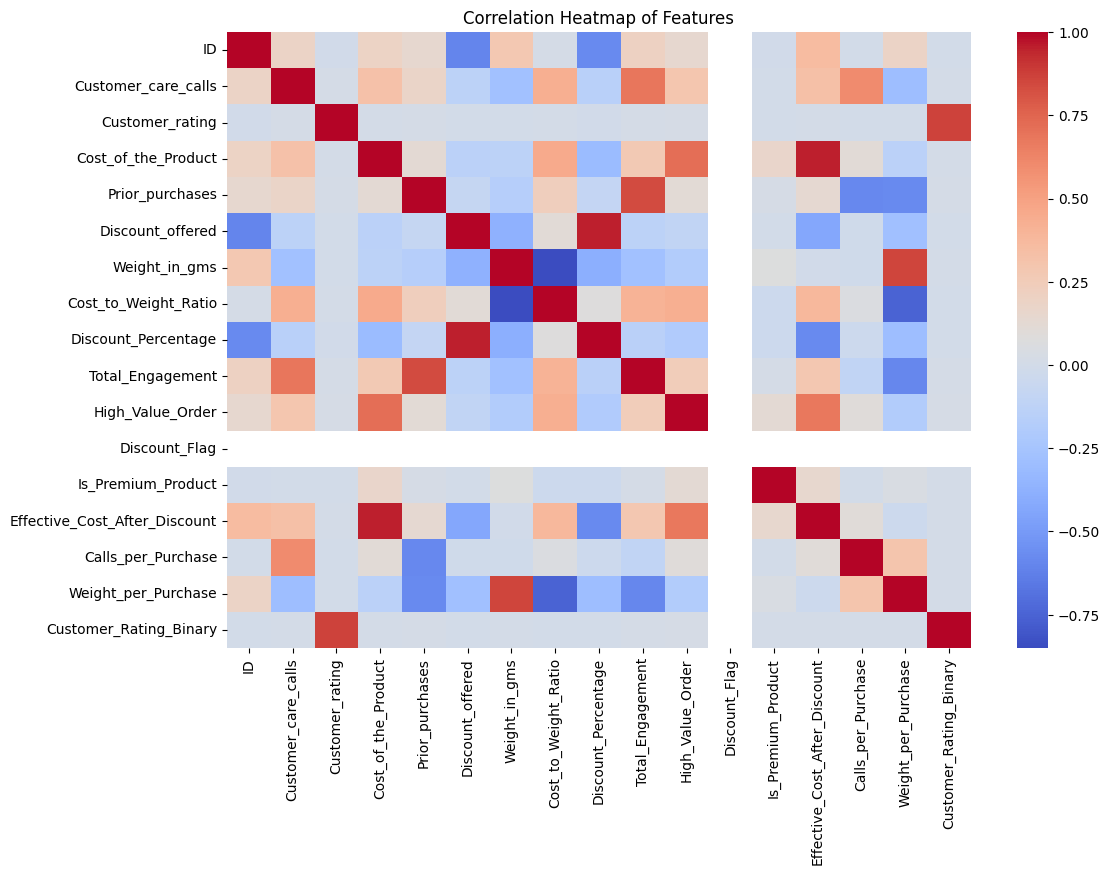

In [ ]:
# 2. Correlation Heatmap - check highly correlated features
plt.figure(figsize=(12,8))
sns.heatmap(X.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap of Features")
plt.show()

In [ ]:
# 3. Variance Inflation Factor (VIF) - detect multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_num = X.select_dtypes(include='number').fillna(0)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_num.columns
vif_data["VIF"] = [variance_inflation_factor(X_num.values, i) for i in range(X_num.shape[1])]
print(vif_data.sort_values(by="VIF", ascending=False))

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                          Feature         VIF
1             Customer_care_calls         inf
13  Effective_Cost_After_Discount         inf
3             Cost_of_the_Product         inf
4                 Prior_purchases         inf
5                Discount_offered         inf
9                Total_Engagement         inf
11                  Discount_Flag  163.978399
6                   Weight_in_gms   22.626642
15            Weight_per_Purchase   22.089604
8             Discount_Percentage   18.478527
14             Calls_per_Purchase   12.287212
7            Cost_to_Weight_Ratio    9.098052
16         Customer_Rating_Binary    3.953524
2                 Customer_rating    3.953142
10               High_Value_Order    2.158371
0                              ID    1.856385
12             Is_Premium_Product    1.052239


In [ ]:
# 4. Chi-Square Test - categorical features vs target
from sklearn.feature_selection import chi2
X_cat = pd.get_dummies(X.select_dtypes(include='object'))
chi_scores = chi2(X_cat, y)
chi2_results = pd.DataFrame({'Feature': X_cat.columns, 'Chi2 Score': chi_scores[0], 'p-value': chi_scores[1]})
print(chi2_results.sort_values(by="Chi2 Score", ascending=False).head(10))

                      Feature   Chi2 Score        p-value
15     Weight_Category_Medium  1205.178311  4.569933e-264
13      Weight_Category_Heavy   672.835889  2.414824e-148
14      Weight_Category_Light    88.398881   5.350106e-21
8     Product_importance_high    11.106674   8.601762e-04
0           Warehouse_block_A     0.795620   3.724062e-01
10  Product_importance_medium     0.769316   3.804286e-01
6       Mode_of_Shipment_Road     0.543731   4.608906e-01
9      Product_importance_low     0.335174   5.626284e-01
1           Warehouse_block_B     0.238925   6.249834e-01
5     Mode_of_Shipment_Flight     0.176215   6.746462e-01


In [ ]:
# 5. ANOVA Test - compare group means for numerical features vs target
from sklearn.feature_selection import f_classif
f_test, p_vals = f_classif(X_num, y)
anova_results = pd.DataFrame({'Feature': X_num.columns, 'F-Score': f_test, 'p-value': p_vals})
print(anova_results.sort_values(by="F-Score", ascending=False).head(10))

                          Feature      F-Score        p-value
0                              ID  2245.979758   0.000000e+00
5                Discount_offered  2058.842985   0.000000e+00
8             Discount_Percentage  1861.505746   0.000000e+00
6                   Weight_in_gms   856.401798  2.354658e-181
15            Weight_per_Purchase   483.458826  6.739309e-105
13  Effective_Cost_After_Discount   406.734875   7.531503e-89
7            Cost_to_Weight_Ratio    84.026500   5.748903e-20
9                Total_Engagement    67.612926   2.213278e-16
3             Cost_of_the_Product    59.873829   1.099886e-14
1             Customer_care_calls    49.775450   1.827535e-12


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [11] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [ ]:
# 6. F-Test - compare variances of two features
from scipy.stats import f
feature1, feature2 = X_num['Cost_of_the_Product'], X_num['Discount_offered']
f_stat = np.var(feature1) / np.var(feature2)
print("F-statistic (Cost vs Discount):", f_stat)

F-statistic (Cost vs Discount): 8.796306214707936


In [ ]:
# 7. Z-Test - test mean difference for n >= 30
from statsmodels.stats.weightstats import ztest
z_stat, p_val = ztest(X_num['Cost_of_the_Product'], value=200)
print("Z-test for mean=200 -> Z-stat:", z_stat, "p-value:", p_val)

Z-test for mean=200 -> Z-stat: 22.249933023714174 p-value: 1.1296130569759058e-109


In [ ]:
# 8. T-Test - test mean difference when n < 30 (taking sample)
from scipy.stats import ttest_1samp
sample = X_num['Weight_in_gms'].sample(25, random_state=42)
t_stat, p_val = ttest_1samp(sample, 3000)
print("T-test on small sample (Weight vs mean=3000):", t_stat, "p-value:", p_val)

T-test on small sample (Weight vs mean=3000): 1.6175946963479908 p-value: 0.11881927316163325


In [ ]:
# 9. Mutual Information - captures nonlinear relationships
from sklearn.feature_selection import mutual_info_classif
mi = mutual_info_classif(X_num, y)
mi_scores = pd.Series(mi, index=X_num.columns).sort_values(ascending=False)
print("Top features by Mutual Information:\n", mi_scores.head(10))

Top features by Mutual Information:
 ID                               0.186273
Discount_offered                 0.155026
Discount_Percentage              0.138570
Weight_in_gms                    0.120909
Cost_to_Weight_Ratio             0.119278
Weight_per_Purchase              0.052503
Effective_Cost_After_Discount    0.025540
Calls_per_Purchase               0.013524
Total_Engagement                 0.009657
Prior_purchases                  0.005222
dtype: float64


In [ ]:
# 10. Hypothesis Testing Summary - p-values vs alpha=0.05
alpha = 0.05
significant_features = anova_results[anova_results['p-value'] < alpha]['Feature']
print("Features significant at alpha=0.05:\n", significant_features.tolist())

Features significant at alpha=0.05:
 ['ID', 'Customer_care_calls', 'Cost_of_the_Product', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms', 'Cost_to_Weight_Ratio', 'Discount_Percentage', 'Total_Engagement', 'High_Value_Order', 'Effective_Cost_After_Discount', 'Weight_per_Purchase']


### Embedded Methods (Model-Based Importance)

In [ ]:
# 1. Logistic Regression with L1 (Lasso)
from sklearn.linear_model import LogisticRegression
lasso = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)
lasso.fit(X_num.fillna(0), y)
lasso_coef = pd.Series(lasso.coef_[0], index=X_num.columns)
print("Top Lasso Features:\n", lasso_coef.sort_values(ascending=False).head(10))

Top Lasso Features:
 Discount_Flag                    1.141795
Calls_per_Purchase               1.029237
Is_Premium_Product               0.149076
Discount_Percentage              0.074546
Discount_offered                 0.051723
Customer_rating                  0.047736
Effective_Cost_After_Discount    0.002354
Cost_of_the_Product              0.000408
Prior_purchases                  0.000000
ID                              -0.000136
dtype: float64


In [ ]:
# 2. Logistic Regression with L2 (Ridge)
ridge = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000)
ridge.fit(X_num.fillna(0), y)
ridge_coef = pd.Series(ridge.coef_[0], index=X_num.columns)
print("Top Ridge Features:\n", ridge_coef.sort_values(ascending=False).head(10))

Top Ridge Features:
 Calls_per_Purchase     0.969068
Discount_Flag          0.750238
Is_Premium_Product     0.192757
Discount_Percentage    0.089037
Customer_rating        0.057403
Prior_purchases        0.041723
Discount_offered       0.031282
Cost_of_the_Product    0.016343
Weight_in_gms          0.000010
ID                    -0.000146
dtype: float64


In [ ]:
# 3. Decision Tree Feature Importance
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_num.fillna(0), y)
dt_importances = pd.Series(dt.feature_importances_, index=X_num.columns)
print("Top Decision Tree Features:\n", dt_importances.sort_values(ascending=False).head(10))

Top Decision Tree Features:
 ID                               0.400549
Cost_to_Weight_Ratio             0.099801
Weight_per_Purchase              0.098157
Discount_Percentage              0.093542
Weight_in_gms                    0.081130
Effective_Cost_After_Discount    0.055643
Cost_of_the_Product              0.052836
Total_Engagement                 0.024851
Customer_rating                  0.024783
Calls_per_Purchase               0.019458
dtype: float64


In [ ]:
# 4. Random Forest Feature Importance
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_num.fillna(0), y)
rf_importances = pd.Series(rf.feature_importances_, index=X_num.columns)
print("Top Random Forest Features:\n", rf_importances.sort_values(ascending=False).head(10))

Top Random Forest Features:
 ID                               0.207339
Discount_Percentage              0.120048
Weight_in_gms                    0.115684
Cost_to_Weight_Ratio             0.100267
Weight_per_Purchase              0.090900
Discount_offered                 0.088402
Effective_Cost_After_Discount    0.075966
Cost_of_the_Product              0.067377
Customer_rating                  0.029528
Calls_per_Purchase               0.029192
dtype: float64


In [ ]:
# 5. Extra Trees Feature Importance
from sklearn.ensemble import ExtraTreesClassifier
et = ExtraTreesClassifier(random_state=42)
et.fit(X_num.fillna(0), y)
et_importances = pd.Series(et.feature_importances_, index=X_num.columns)
print("Top Extra Trees Features:\n", et_importances.sort_values(ascending=False).head(10))

Top Extra Trees Features:
 ID                               0.165286
Weight_in_gms                    0.110032
Discount_offered                 0.102552
Discount_Percentage              0.101512
Cost_to_Weight_Ratio             0.095632
Weight_per_Purchase              0.083661
Effective_Cost_After_Discount    0.076151
Cost_of_the_Product              0.071285
Customer_rating                  0.042292
Total_Engagement                 0.033855
dtype: float64


In [ ]:
# 6. Gradient Boosting Feature Importance
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_num.fillna(0), y)
gb_importances = pd.Series(gb.feature_importances_, index=X_num.columns)
print("Top Gradient Boosting Features:\n", gb_importances.sort_values(ascending=False).head(10))

Top Gradient Boosting Features:
 ID                               0.899188
Cost_to_Weight_Ratio             0.025418
Weight_in_gms                    0.017929
Discount_Percentage              0.015808
Weight_per_Purchase              0.012161
Effective_Cost_After_Discount    0.009959
Cost_of_the_Product              0.005280
Discount_offered                 0.003211
Customer_rating                  0.003168
Calls_per_Purchase               0.002588
dtype: float64


In [ ]:
# 7. XGBoost Feature Importance
from xgboost import XGBClassifier
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_num.fillna(0), y)
xgb_importances = pd.Series(xgb.feature_importances_, index=X_num.columns)
print("Top XGBoost Features:\n", xgb_importances.sort_values(ascending=False).head(10))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:41:17] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Top XGBoost Features:
 ID                               0.337995
Customer_care_calls              0.055696
Cost_to_Weight_Ratio             0.055215
Discount_Percentage              0.055166
Prior_purchases                  0.054210
Effective_Cost_After_Discount    0.053526
Calls_per_Purchase               0.049498
Is_Premium_Product               0.049120
Cost_of_the_Product              0.049113
Customer_rating                  0.049112
dtype: float32


In [ ]:
# 8. Permutation Importance (with Random Forest)
from sklearn.inspection import permutation_importance
perm = permutation_importance(rf, X_num.fillna(0), y, n_repeats=10, random_state=42)
perm_importances = pd.Series(perm.importances_mean, index=X_num.columns)
print("Top Permutation Importances:\n", perm_importances.sort_values(ascending=False).head(10))

Top Permutation Importances:
 ID                               0.156778
Weight_in_gms                    0.093390
Discount_Percentage              0.040422
Cost_to_Weight_Ratio             0.030676
Weight_per_Purchase              0.030057
Discount_offered                 0.026330
Effective_Cost_After_Discount    0.010746
Cost_of_the_Product              0.010646
Customer_rating                  0.010146
Calls_per_Purchase               0.001018
dtype: float64


In [ ]:
# 9. SelectFromModel with Gradient Boosting - Embedded Method
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.feature_selection import SelectFromModel

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_num.fillna(0), y)

sfm = SelectFromModel(gb, prefit=True, threshold="median")
selected_features = X_num.columns[sfm.get_support()]

print("Gradient Boosting Selected Features:", list(selected_features))

Gradient Boosting Selected Features: ['ID', 'Customer_rating', 'Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms', 'Cost_to_Weight_Ratio', 'Discount_Percentage', 'Effective_Cost_After_Discount', 'Weight_per_Purchase']


In [ ]:
# 10. Stability Selection - average feature importance across runs
importances_list = []
for seed in [10, 20, 30, 40, 50]:
    rf_temp = RandomForestClassifier(random_state=seed)
    rf_temp.fit(X_num.fillna(0), y)
    importances_list.append(rf_temp.feature_importances_)
stability = pd.DataFrame(importances_list, columns=X_num.columns).mean().sort_values(ascending=False)
print("Stable Importances Across Runs:\n", stability.head(10))

Stable Importances Across Runs:
 ID                               0.199132
Discount_Percentage              0.121967
Weight_in_gms                    0.112256
Cost_to_Weight_Ratio             0.102930
Weight_per_Purchase              0.093356
Discount_offered                 0.092205
Effective_Cost_After_Discount    0.072869
Cost_of_the_Product              0.068148
Customer_rating                  0.030570
Calls_per_Purchase               0.029158
dtype: float64


### Wrapper Methods (Iterative Search)

In [ ]:
# 1. SelectFromModel with Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectFromModel

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_num.fillna(0), y)
sfm_dt = SelectFromModel(dt, prefit=True, threshold="median")

selected_features = list(X_num.columns[sfm_dt.get_support()])

print("Decision Tree Selected Features:")
for feature in selected_features:
    print(feature)

Decision Tree Selected Features:
ID
Customer_care_calls
Customer_rating
Cost_of_the_Product
Prior_purchases
Discount_offered
Weight_in_gms
Cost_to_Weight_Ratio
Discount_Percentage
Total_Engagement
High_Value_Order
Discount_Flag
Is_Premium_Product
Effective_Cost_After_Discount
Calls_per_Purchase
Weight_per_Purchase
Customer_Rating_Binary


In [ ]:
# 2. SelectFromModel with Random Forest
rf = RandomForestClassifier(n_estimators=50, random_state=42)
rf.fit(X_num.fillna(0), y)
sfm_rf = SelectFromModel(rf, prefit=True, threshold="median")

selected_features = list(X_num.columns[sfm_rf.get_support()])
print("Random Forest Selected Features:")
for f in selected_features:
    print(f)

Random Forest Selected Features:
ID
Customer_rating
Cost_of_the_Product
Discount_offered
Weight_in_gms
Cost_to_Weight_Ratio
Discount_Percentage
Effective_Cost_After_Discount
Weight_per_Purchase


In [ ]:
# 3. SelectFromModel with Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_num.fillna(0), y)
sfm_gb = SelectFromModel(gb, prefit=True, threshold="median")

print("Gradient Boosting Selected Features:")
for f in X_num.columns[sfm_gb.get_support()]:
    print(f)

Gradient Boosting Selected Features:
ID
Customer_rating
Cost_of_the_Product
Discount_offered
Weight_in_gms
Cost_to_Weight_Ratio
Discount_Percentage
Effective_Cost_After_Discount
Weight_per_Purchase


In [ ]:
# 4. Top-K Feature Selection using Random Forest Importance
rf = RandomForestClassifier(n_estimators=30, random_state=42)
rf.fit(X_num.fillna(0), y)

top_features = X_num.columns[np.argsort(rf.feature_importances_)[-10:]]

print("Top 10 Features by RF Importance:")
for f in top_features:
    print(f)

Top 10 Features by RF Importance:
Calls_per_Purchase
Customer_rating
Cost_of_the_Product
Effective_Cost_After_Discount
Weight_per_Purchase
Cost_to_Weight_Ratio
Discount_offered
Weight_in_gms
Discount_Percentage
ID


In [ ]:
# 5. Quick Backward Elimination using Variance
low_var = X_num.var().sort_values().head(5).index
X_backward = X_num.drop(low_var, axis=1)

print("Removed Low-Variance Features:")
for f in low_var:
    print(f)

print("\nRemaining Features:")
for f in X_backward.columns:
    print(f)

Removed Low-Variance Features:
Discount_Flag
Cost_to_Weight_Ratio
Is_Premium_Product
Calls_per_Purchase
High_Value_Order

Remaining Features:
ID
Customer_care_calls
Customer_rating
Cost_of_the_Product
Prior_purchases
Discount_offered
Weight_in_gms
Discount_Percentage
Total_Engagement
Effective_Cost_After_Discount
Weight_per_Purchase
Customer_Rating_Binary


In [ ]:
# 6. Quick Forward Selection (Random Forest Top 10 by importance)
rf_top10 = X_num.columns[np.argsort(rf.feature_importances_)[-10:]]

print("Forward Selection Approx (Top 10 RF):")
for f in rf_top10:
    print(f)

Forward Selection Approx (Top 10 RF):
Calls_per_Purchase
Customer_rating
Cost_of_the_Product
Effective_Cost_After_Discount
Weight_per_Purchase
Cost_to_Weight_Ratio
Discount_offered
Weight_in_gms
Discount_Percentage
ID


In [ ]:
# 7. Quick Backward Elimination (drop 5 lowest variance features)
low_var = X_num.var().sort_values().head(5).index
X_backward = X_num.drop(low_var, axis=1)

print("Backward Elimination Approx - Removed:")
for f in low_var:
    print(f)

print("\nRemaining Features:")
for f in X_backward.columns:
    print(f)

Backward Elimination Approx - Removed:
Discount_Flag
Cost_to_Weight_Ratio
Is_Premium_Product
Calls_per_Purchase
High_Value_Order

Remaining Features:
ID
Customer_care_calls
Customer_rating
Cost_of_the_Product
Prior_purchases
Discount_offered
Weight_in_gms
Discount_Percentage
Total_Engagement
Effective_Cost_After_Discount
Weight_per_Purchase
Customer_Rating_Binary


In [ ]:
# 8. Wrapper-style Random Subset Evaluation
import random
subset = random.sample(list(X_num.columns), 10)
rf = RandomForestClassifier(n_estimators=30, random_state=42)
rf.fit(X_num[subset].fillna(0), y)

print("Random Subset of Features:")
for f in subset:
    print(f)
print("\nAccuracy with random subset:", rf.score(X_num[subset].fillna(0), y))

Random Subset of Features:
Total_Engagement
Discount_Percentage
Customer_care_calls
Prior_purchases
Discount_Flag
Cost_to_Weight_Ratio
Calls_per_Purchase
Effective_Cost_After_Discount
High_Value_Order
Weight_per_Purchase

Accuracy with random subset: 0.9992726611510138


In [ ]:
# 9. Compare Wrapper (RFE RF) vs Embedded (RF importance)
print("Wrapper (RFE RF) Features:")
for f in X_num.columns[rfe_rf.support_]:
    print(f)

print("\nEmbedded (RF Top 10) Features:")
for f in rf_top10:
    print(f)

Wrapper (RFE RF) Features:
ID
Customer_rating
Cost_of_the_Product
Discount_offered
Weight_in_gms
Cost_to_Weight_Ratio
Discount_Percentage
Effective_Cost_After_Discount
Calls_per_Purchase
Weight_per_Purchase

Embedded (RF Top 10) Features:
Calls_per_Purchase
Customer_rating
Cost_of_the_Product
Effective_Cost_After_Discount
Weight_per_Purchase
Cost_to_Weight_Ratio
Discount_offered
Weight_in_gms
Discount_Percentage
ID


In [ ]:
# 10. Stability Selection with RF (average importances across runs)
importances_list = []
for seed in [10, 20, 30]:
    rf_temp = RandomForestClassifier(n_estimators=30, random_state=seed)
    rf_temp.fit(X_num.fillna(0), y)
    importances_list.append(rf_temp.feature_importances_)

stability = pd.DataFrame(importances_list, columns=X_num.columns).mean().sort_values(ascending=False)

print("Stable Features Across Runs:")
for f in stability.head(10).index:
    print(f)

Stable Features Across Runs:
ID
Discount_Percentage
Weight_in_gms
Cost_to_Weight_Ratio
Weight_per_Purchase
Discount_offered
Effective_Cost_After_Discount
Cost_of_the_Product
Customer_rating
Calls_per_Purchase


# 3. Model Training & Hyperparameter Tuning

In [3]:
!pip install category-encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 2.6 MB/s eta 0:00:00


In [1]:
!pip install optuna
!pip install xgboost lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 4.9 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, classification_report, matthews_corrcoef
)
from category_encoders import TargetEncoder
import optuna

# Models (Imported upfront)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC

# Attempt to import Boosting models
try:
    from xgboost import XGBClassifier
    from lightgbm import LGBMClassifier
except ImportError:
    print("XGBoost/LightGBM not found. Using scikit-learn's GradientBoostingClassifier for Boosting.")
    XGBClassifier = None
    LGBMClassifier = None


warnings.filterwarnings('ignore')
RANDOM_STATE = 42
TARGET_COLUMN = 'Reached.on.Time_Y.N'

In [5]:
# --- 1. Load Data ---

import kagglehub

try:
    # Using the Kaggle path as requested
    # Download latest version
    path = kagglehub.dataset_download("prachi13/customer-analytics")
    print("Path to dataset files:", path)
    # Load dataset into df
    df = pd.read_csv("/kaggle/input/customer-analytics/Train.csv")
    df = df.drop(columns=['ID'])
except FileNotFoundError:
    print("FATAL ERROR: 'Train.csv' not found at the specified path. Please check the file location.")
    # Exiting the block execution if data is missing
    raise

Using Colab cache for faster access to the 'customer-analytics' dataset.
Path to dataset files: /kaggle/input/customer-analytics


In [6]:
# --- 2. Feature Engineering (12 Features) ---
df['Cost_to_Weight_Ratio'] = df['Cost_of_the_Product'] / df['Weight_in_gms']
df['Discount_Percentage'] = (df['Discount_offered'] / df['Cost_of_the_Product']) * 100
df['Total_Engagement'] = df['Customer_care_calls'] + df['Prior_purchases']
df['High_Value_Order'] = np.where(df['Cost_of_the_Product'] > 250, 1, 0)
df['Weight_Category'] = pd.cut(df['Weight_in_gms'],
                               bins=[0, 2000, 4000, np.inf],
                               labels=['Light', 'Medium', 'Heavy'],
                               include_lowest=True).astype(object)
df['Discount_Flag'] = np.where(df['Discount_offered'] > 0, 1, 0)
df['Is_Premium_Product'] = np.where((df['Product_importance'] == 'high') &
                                    (df['Cost_of_the_Product'] > 220), 1, 0)
df['Effective_Cost_After_Discount'] = df['Cost_of_the_Product'] - df['Discount_offered']
df['Calls_per_Purchase'] = df['Customer_care_calls'] / (df['Prior_purchases'] + 1)
df['Weight_per_Purchase'] = df['Weight_in_gms'] / (df['Prior_purchases'] + 1)
df['Customer_Rating_Binary'] = np.where(df['Customer_rating'] >= 4, 1, 0)
df['Prior_Purchases_Flag'] = np.where(df['Prior_purchases'] > 0, 1, 0)

In [7]:
# --- 3. Data Split: Train (70%), Validation (15%), Test (15%) ---
X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

# Step 1: Split 85% Train/Validation and 15% Test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y)

# Step 2: Split remaining 85% into 70% Train and 15% Validation (15/85 ≈ 0.176)
val_split_ratio = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_split_ratio, random_state=RANDOM_STATE, stratify=y_temp)

print(f"Data Split: Train={len(X_train)} (70%), Validation={len(X_val)} (15%), Test={len(X_test)} (15%)")

Data Split: Train=7699 (70%), Validation=1650 (15%), Test=1650 (15%)


In [8]:
# --- 4. Preprocessing Pipeline Definition ---
NUMERICAL_FEATURES = [col for col in X_train.columns if df[col].dtype in ['int64', 'float64'] and col not in ['Customer_rating', 'High_Value_Order', 'Discount_Flag', 'Is_Premium_Product', 'Customer_Rating_Binary', 'Prior_Purchases_Flag']]
NOMINAL_FEATURES_OHE = ['Warehouse_block', 'Mode_of_Shipment', 'Gender'] # One-Hot Encoding
NOMINAL_FEATURES_TARGET_ENCODING = ['Weight_Category'] # Target Guided Encoding
ORDINAL_FEATURES = ['Product_importance'] # Ordinal Encoding
BINARY_FEATURES = [col for col in X_train.columns if col not in NUMERICAL_FEATURES + NOMINAL_FEATURES_OHE + NOMINAL_FEATURES_TARGET_ENCODING + ORDINAL_FEATURES]


# Target Guided Encoding (Fit only on TRAIN data)
target_encoder = TargetEncoder(cols=NOMINAL_FEATURES_TARGET_ENCODING)
target_encoder.fit(X_train, y_train)

# Apply Target Encoding to all sets
X_train_te = target_encoder.transform(X_train)
X_val_te = target_encoder.transform(X_val)
X_test_te = target_encoder.transform(X_test)

# Final Feature Lists for ColumnTransformer
NUMERICAL_FEATURES_FINAL = NUMERICAL_FEATURES + NOMINAL_FEATURES_TARGET_ENCODING # Target Encoded feature now treated as numerical


numerical_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
ohe_pipeline = Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
ordinal_pipeline = Pipeline([('ordinal', OrdinalEncoder(categories=[['low', 'medium', 'high']]))])

# Final Preprocessor (fits on X_train_te)
final_preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, NUMERICAL_FEATURES_FINAL),
        ('nom_ohe', ohe_pipeline, NOMINAL_FEATURES_OHE),
        ('ord', ordinal_pipeline, ORDINAL_FEATURES)
    ],
    remainder='passthrough'
)

print("\nFeature Engineering and Preprocessing (Target, One-Hot, Ordinal Encoding) Complete.")


Feature Engineering and Preprocessing (Target, One-Hot, Ordinal Encoding) Complete.


In [9]:
# --- Optuna Hyperparameter Tuning Setup ---

def objective(trial, X_train, y_train, X_val, y_val, preprocessor, model_name):
    """Objective function for Optuna to maximize ROC_AUC on the Validation set."""

    if model_name == 'RandomForest':
        n_estimators = trial.suggest_int('n_estimators', 50, 300, step=50)
        max_depth = trial.suggest_int('max_depth', 3, 15)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20)

        model = RandomForestClassifier(
            n_estimators=n_estimators, max_depth=max_depth, min_samples_split=min_samples_split,
            random_state=RANDOM_STATE, n_jobs=-1
        )
    elif model_name == 'LogisticRegression':
        C = trial.suggest_loguniform('C', 1e-4, 1e2)
        penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
        solver = 'liblinear'

        model = LogisticRegression(C=C, penalty=penalty, solver=solver, random_state=RANDOM_STATE)

    # Create the full pipeline
    full_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])

    # Train on Training data
    full_pipeline.fit(X_train, y_train)

    # Evaluate on Validation data
    y_pred_proba = full_pipeline.predict_proba(X_val)[:, 1]
    roc_auc = roc_auc_score(y_val, y_pred_proba)

    # Store the model object in the trial for later retrieval
    trial.set_user_attr('classifier', model)

    return roc_auc


def run_optuna_tuning(X_train, y_train, X_val, y_val, preprocessor, model_name, n_trials=30):
    """Runs the Optuna study and returns the best model and score."""
    study = optuna.create_study(direction='maximize', study_name=f'{model_name}_Tuning')

    func = lambda trial: objective(trial, X_train, y_train, X_val, y_val, preprocessor, model_name)

    study.optimize(func, n_trials=n_trials, show_progress_bar=True)

    print(f"\n--- Optuna Study Results for {model_name} ---")
    print(f"Best ROC-AUC on Validation Set: {study.best_value:.4f}")
    print(f"Best Parameters: {study.best_params}")

    # Re-train the best model using the best parameters
    best_model_params = study.best_params
    if model_name == 'RandomForest':
        best_model = RandomForestClassifier(**best_model_params, random_state=RANDOM_STATE, n_jobs=-1)
    elif model_name == 'LogisticRegression':
        best_model = LogisticRegression(**best_model_params, solver='liblinear', random_state=RANDOM_STATE)

    return best_model, study.best_value

# Helper function to run final evaluation on the Test set
def final_test_evaluation(model, model_name, X_test, y_test, preprocessor):
    # Combine Train + Validation for the final model training
    X_train_val = pd.concat([X_train_te, X_val_te])
    y_train_val = pd.concat([y_train, y_val])

    full_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    full_pipeline.fit(X_train_val, y_train_val)

    y_pred = full_pipeline.predict(X_test)
    y_proba = full_pipeline.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    # Metrics
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred), # <--- ACCURACY ADDED HERE
        'F1-Score': f1_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'MCC': matthews_corrcoef(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    }

    # ROC Curve Data
    fpr, tpr, _ = roc_curve(y_test, y_proba) if y_proba is not None else (None, None, None)

    print(f"\n--- Final Test Set Evaluation for {model_name} ---")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {metrics['Accuracy']:.4f} | ROC-AUC: {metrics['ROC-AUC']:.4f} | F1-Score: {metrics['F1-Score']:.4f} | MCC: {metrics['MCC']:.4f}")

    return metrics, fpr, tpr

In [10]:
print("\n" + "="*80)
print("A. MODEL 1: LOGISTIC REGRESSION (Tuned with Optuna)")
print("="*80)

best_lr_model, val_score = run_optuna_tuning(X_train_te, y_train, X_val_te, y_val, final_preprocessor, 'LogisticRegression', n_trials=20)
lr_metrics, lr_fpr, lr_tpr = final_test_evaluation(best_lr_model, 'Logistic Regression (Tuned)', X_test_te, y_test, final_preprocessor)

[I 2025-10-06 13:02:08,177] A new study created in memory with name: LogisticRegression_Tuning



A. MODEL 1: LOGISTIC REGRESSION (Tuned with Optuna)


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-10-06 13:02:08,329] Trial 0 finished with value: 0.7311976610757098 and parameters: {'C': 15.994222415741369, 'penalty': 'l2'}. Best is trial 0 with value: 0.7311976610757098.
[I 2025-10-06 13:02:08,841] Trial 1 finished with value: 0.7311854537464293 and parameters: {'C': 5.791768432363072, 'penalty': 'l1'}. Best is trial 0 with value: 0.7311976610757098.
[I 2025-10-06 13:02:09,505] Trial 2 finished with value: 0.7311839278302693 and parameters: {'C': 29.80069825729287, 'penalty': 'l1'}. Best is trial 0 with value: 0.7311976610757098.
[I 2025-10-06 13:02:09,586] Trial 3 finished with value: 0.7313365194462755 and parameters: {'C': 0.020184682339324994, 'penalty': 'l1'}. Best is trial 3 with value: 0.7313365194462755.
[I 2025-10-06 13:02:09,665] Trial 4 finished with value: 0.7301402011767865 and parameters: {'C': 0.005529785656882991, 'penalty': 'l2'}. Best is trial 3 with value: 0.7313365194462755.
[I 2025-10-06 13:02:09,756] Trial 5 finished with value: 0.7328731170194585 an

In [11]:
print("\n" + "="*80)
print("B. MODEL 2: NAIVE BAYES CLASSIFICATION")
print("="*80)

nb_model = GaussianNB()
nb_metrics, nb_fpr, nb_tpr = final_test_evaluation(nb_model, 'Naive Bayes', X_test_te, y_test, final_preprocessor)


B. MODEL 2: NAIVE BAYES CLASSIFICATION

--- Final Test Set Evaluation for Naive Bayes ---
              precision    recall  f1-score   support

           0       0.55      0.99      0.71       665
           1       0.98      0.46      0.63       985

    accuracy                           0.67      1650
   macro avg       0.77      0.72      0.67      1650
weighted avg       0.81      0.67      0.66      1650

Accuracy: 0.6715 | ROC-AUC: 0.7425 | F1-Score: 0.6252 | MCC: 0.4868


In [12]:
print("\n" + "="*80)
print("C. MODEL 3: RANDOM FOREST (Tuned with Optuna - Represents Bagging)")
print("="*80)

best_rf_model, val_score = run_optuna_tuning(X_train_te, y_train, X_val_te, y_val, final_preprocessor, 'RandomForest', n_trials=30)
rf_metrics, rf_fpr, rf_tpr = final_test_evaluation(best_rf_model, 'Random Forest (Tuned)', X_test_te, y_test, final_preprocessor)

[I 2025-10-06 13:02:21,430] A new study created in memory with name: RandomForest_Tuning



C. MODEL 3: RANDOM FOREST (Tuned with Optuna - Represents Bagging)


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-10-06 13:02:24,236] Trial 0 finished with value: 0.7087834786005518 and parameters: {'n_estimators': 250, 'max_depth': 15, 'min_samples_split': 10}. Best is trial 0 with value: 0.7087834786005518.
[I 2025-10-06 13:02:26,050] Trial 1 finished with value: 0.7174369491442663 and parameters: {'n_estimators': 150, 'max_depth': 7, 'min_samples_split': 5}. Best is trial 1 with value: 0.7174369491442663.
[I 2025-10-06 13:02:28,042] Trial 2 finished with value: 0.7115041871139431 and parameters: {'n_estimators': 150, 'max_depth': 9, 'min_samples_split': 3}. Best is trial 1 with value: 0.7174369491442663.
[I 2025-10-06 13:02:30,724] Trial 3 finished with value: 0.7115774310896262 and parameters: {'n_estimators': 250, 'max_depth': 14, 'min_samples_split': 10}. Best is trial 1 with value: 0.7174369491442663.
[I 2025-10-06 13:02:34,295] Trial 4 finished with value: 0.716626687663273 and parameters: {'n_estimators': 300, 'max_depth': 7, 'min_samples_split': 3}. Best is trial 1 with value: 0.

In [13]:
print("\n" + "="*80)
print("D. MODEL 4: BOOSTING (XGBOOST/GRADIENT BOOSTING)")
print("="*80)

if XGBClassifier:
    boosting_model = XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE)
    model_name = 'XGBoost (Boosting)'
elif LGBMClassifier:
    boosting_model = LGBMClassifier(n_estimators=100, random_state=RANDOM_STATE, verbose=-1)
    model_name = 'LightGBM (Boosting)'
else:
    # Fallback to Gradient Boosting
    boosting_model = GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)
    model_name = 'Gradient Boosting (Boosting)'

boosting_metrics, boosting_fpr, boosting_tpr = final_test_evaluation(boosting_model, model_name, X_test_te, y_test, final_preprocessor)


D. MODEL 4: BOOSTING (XGBOOST/GRADIENT BOOSTING)

--- Final Test Set Evaluation for XGBoost (Boosting) ---
              precision    recall  f1-score   support

           0       0.57      0.69      0.63       665
           1       0.76      0.65      0.70       985

    accuracy                           0.67      1650
   macro avg       0.67      0.67      0.66      1650
weighted avg       0.68      0.67      0.67      1650

Accuracy: 0.6685 | ROC-AUC: 0.7437 | F1-Score: 0.7022 | MCC: 0.3372


In [14]:
print("\n" + "="*80)
print("E. MODEL 5: SVM CLASSIFICATION (SVC)")
print("="*80)

# Using a standard kernel for initial comparison
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE, probability=True)
svm_metrics, svm_fpr, svm_tpr = final_test_evaluation(svm_model, 'SVM Classification (SVC)', X_test_te, y_test, final_preprocessor)


E. MODEL 5: SVM CLASSIFICATION (SVC)

--- Final Test Set Evaluation for SVM Classification (SVC) ---
              precision    recall  f1-score   support

           0       0.56      0.98      0.71       665
           1       0.98      0.47      0.63       985

    accuracy                           0.68      1650
   macro avg       0.77      0.73      0.67      1650
weighted avg       0.81      0.68      0.66      1650

Accuracy: 0.6764 | ROC-AUC: 0.7307 | F1-Score: 0.6337 | MCC: 0.4908


In [15]:
print("\n" + "="*80)
print("F. MODEL 6: ENSEMBLE LEARNING (Stacking)")
print("="*80)

# Use the best performing models as base estimators
estimators = [
    ('lr', best_lr_model if 'best_lr_model' in locals() else LogisticRegression(solver='liblinear')),
    ('rf', best_rf_model if 'best_rf_model' in locals() else RandomForestClassifier(n_estimators=100)),
    ('gbc', GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE))
]

stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(solver='liblinear', random_state=RANDOM_STATE),
    cv=3,
    n_jobs=-1
)

stacking_metrics, stacking_fpr, stacking_tpr = final_test_evaluation(stacking_clf, 'Stacking Classifier', X_test_te, y_test, final_preprocessor)


F. MODEL 6: ENSEMBLE LEARNING (Stacking)

--- Final Test Set Evaluation for Stacking Classifier ---
              precision    recall  f1-score   support

           0       0.57      0.79      0.66       665
           1       0.81      0.59      0.68       985

    accuracy                           0.67      1650
   macro avg       0.69      0.69      0.67      1650
weighted avg       0.71      0.67      0.68      1650

Accuracy: 0.6733 | ROC-AUC: 0.7365 | F1-Score: 0.6839 | MCC: 0.3816



4. FINAL MODEL COMPARISON AND ROC CURVE

COMPREHENSIVE MODEL PERFORMANCE COMPARISON (on Final Test Set)
Metrics: ACCURACY, Precision, Recall, F1-Score, MCC, ROC-AUC
| Model                       |   Accuracy |   F1-Score |   Recall |   Precision |    MCC |   ROC-AUC |
|:----------------------------|-----------:|-----------:|---------:|------------:|-------:|----------:|
| XGBoost (Boosting)          |     0.6685 |     0.7022 |   0.6548 |      0.7570 | 0.3372 |    0.7437 |
| Logistic Regression (Tuned) |     0.6764 |     0.6903 |   0.6041 |      0.8051 | 0.3822 |    0.7363 |
| Stacking Classifier         |     0.6733 |     0.6839 |   0.5919 |      0.8097 | 0.3816 |    0.7365 |
| Random Forest (Tuned)       |     0.6733 |     0.6801 |   0.5817 |      0.8186 | 0.3878 |    0.7374 |
| SVM Classification (SVC)    |     0.6764 |     0.6337 |   0.4690 |      0.9767 | 0.4908 |    0.7307 |
| Naive Bayes                 |     0.6715 |     0.6252 |   0.4589 |      0.9805 | 0.4868 |    0.7425 |


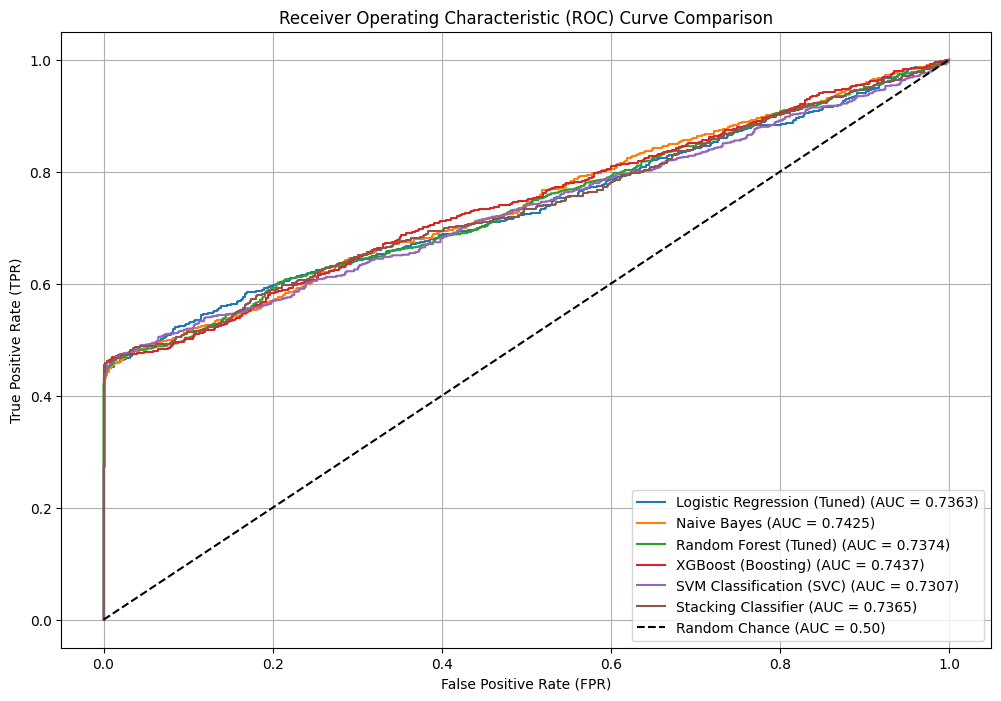

In [16]:
print("\n" + "="*80)
print("4. FINAL MODEL COMPARISON AND ROC CURVE")
print("="*80)

# Gather metrics from all runs
overall_metrics = [lr_metrics, nb_metrics, rf_metrics, boosting_metrics, svm_metrics, stacking_metrics]

comparison_df = pd.DataFrame(overall_metrics).set_index('Model').sort_values(by='F1-Score', ascending=False)
print("\n" + "="*100)
print("COMPREHENSIVE MODEL PERFORMANCE COMPARISON (on Final Test Set)")
print("Metrics: ACCURACY, Precision, Recall, F1-Score, MCC, ROC-AUC")
print("="*100)
print(comparison_df.to_markdown(floatfmt=".4f"))
print("="*100)


# Plotting ROC Curve
roc_data = [
    {'Model': lr_metrics['Model'], 'FPR': lr_fpr, 'TPR': lr_tpr, 'ROC-AUC': lr_metrics['ROC-AUC']},
    {'Model': nb_metrics['Model'], 'FPR': nb_fpr, 'TPR': nb_tpr, 'ROC-AUC': nb_metrics['ROC-AUC']},
    {'Model': rf_metrics['Model'], 'FPR': rf_fpr, 'TPR': rf_tpr, 'ROC-AUC': rf_metrics['ROC-AUC']},
    {'Model': boosting_metrics['Model'], 'FPR': boosting_fpr, 'TPR': boosting_tpr, 'ROC-AUC': boosting_metrics['ROC-AUC']},
    {'Model': svm_metrics['Model'], 'FPR': svm_fpr, 'TPR': svm_tpr, 'ROC-AUC': svm_metrics['ROC-AUC']},
    {'Model': stacking_metrics['Model'], 'FPR': stacking_fpr, 'TPR': stacking_tpr, 'ROC-AUC': stacking_metrics['ROC-AUC']},
]

plt.figure(figsize=(12, 8))

for item in roc_data:
    plt.plot(item['FPR'], item['TPR'], label=f"{item['Model']} (AUC = {item['ROC-AUC']:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.50)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()